<a href="https://colab.research.google.com/github/sheerazshyk671/ML_Labs/blob/main/lab3_Sheerazahmed_churn_dt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## NAME: SHEERAZ AHMED

## CMS ID: 023-24-0171

## SEC: F
# Github: https://github.com/sheerazshyk671/ML_Labs

## ML LAB 3

# Part 1

**Task 1**

In [2]:
import pandas as pd
df=pd.read_csv('clean_churn.csv')
print(df.shape)
print(df.info())
print(df.isnull().sum())

(7005, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7005 entries, 0 to 7004
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7005 non-null   object 
 1   SeniorCitizen     7005 non-null   int64  
 2   Partner           7005 non-null   object 
 3   Dependents        7005 non-null   object 
 4   tenure            7005 non-null   int64  
 5   PhoneService      7005 non-null   object 
 6   MultipleLines     7005 non-null   object 
 7   InternetService   7005 non-null   object 
 8   OnlineSecurity    7005 non-null   object 
 9   OnlineBackup      7005 non-null   object 
 10  DeviceProtection  7005 non-null   object 
 11  TechSupport       7005 non-null   object 
 12  StreamingTV       7005 non-null   object 
 13  StreamingMovies   7005 non-null   object 
 14  Contract          7005 non-null   object 
 15  PaperlessBilling  7005 non-null   object 
 16  PaymentMethod     7005 non-null

**Task 2**

prediction goal: we are building a model to predict if a customer will leave or stay using their past data

business value: if the company knows who might leave they can give them special deals to keep them

# Part 2

**Task 3**

In [3]:
y=df['Churn'].map({'Yes':1,'No':0})
X=df.drop(columns=['Churn'])

**Task4**

In [4]:
X=pd.get_dummies(X,drop_first=True,dtype=int)

**Task 5**

In [5]:
print(X.isnull().sum().sum())
print(X.dtypes)

0
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes                            int64
StreamingTV_No internet service            int64
StreamingTV_Yes   

# Part 3

Task 6

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Task 7

In [7]:
print(X_train.shape,X_test.shape)
print(y_train.shape,y_test.shape)

(5604, 29) (1401, 29)
(5604,) (1401,)


# Part 4

Task 8

In [8]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
train_preds=dt.predict(X_train)
test_preds=dt.predict(X_test)
print(train_preds)
print(test_preds)

[0 1 0 ... 0 0 1]
[0 0 0 ... 1 0 1]


Task 9

In [9]:
print(dt.get_depth())

27


# Part 5

Task 10

In [10]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
acc=accuracy_score(y_test,test_preds)
prec=precision_score(y_test,test_preds)
rec=recall_score(y_test,test_preds)
f1=f1_score(y_test,test_preds)
metrics_table=pd.DataFrame({'Accuracy':[acc],'Precision':[prec],'Recall':[rec],'F1_Score':[f1]})
print(metrics_table)

   Accuracy  Precision   Recall  F1_Score
0   0.73162   0.493113  0.48248  0.487738


Task 11

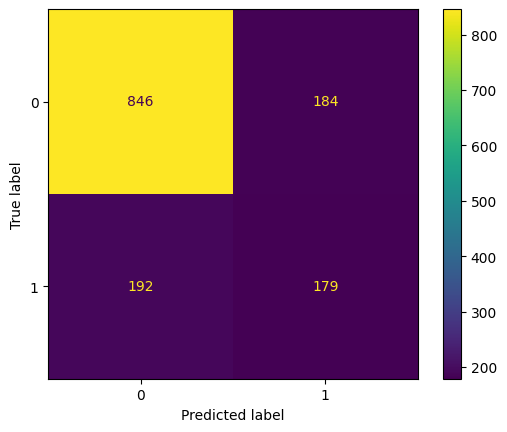

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,test_preds)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

the model correctly caught 179 actual churners and
it completely missed 192 actual churners

Task 12

recall: our main business goal is to catch the customers who are going to leave so we can offer them deals recall specifically measures how many of the true churners our model successfully identified

f1-score: it mathematically balances both precision and recall into one number, proving that the model is genuinely performing well on the the churners instead of just guessing safely

# Part 6

Task 13

In [12]:
train_acc=accuracy_score(y_train,train_preds)
print(train_acc)
print(acc)

0.9976802284082797
0.7316202712348323


yes there is a massive gap the training accuracy is 0.99 (nearly 100%) because the unrestricted tree memorized the training set the test accuracy is much lower (around 73%) this large gap proves that the baseline model heavily overfit the training data and fails to generalize to new customers

Task 14

In [13]:
depths=[2,3,4,5,6,8,10,None]
train_accuracies=[]
test_accuracies=[]
for k in depths:
    dt=DecisionTreeClassifier(max_depth=k,random_state=42)
    dt.fit(X_train,y_train)
    train_accuracies.append(accuracy_score(y_train,dt.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test,dt.predict(X_test)))
results_df=pd.DataFrame({'max_depth':depths,'train_acc':train_accuracies,'test_acc':test_accuracies})
print(results_df)

   max_depth  train_acc  test_acc
0        2.0   0.791756  0.784440
1        3.0   0.791756  0.784440
2        4.0   0.796039  0.783726
3        5.0   0.801570  0.783726
4        6.0   0.807102  0.787295
5        8.0   0.832263  0.788722
6       10.0   0.870985  0.765168
7        NaN   0.997680  0.731620


Task 15

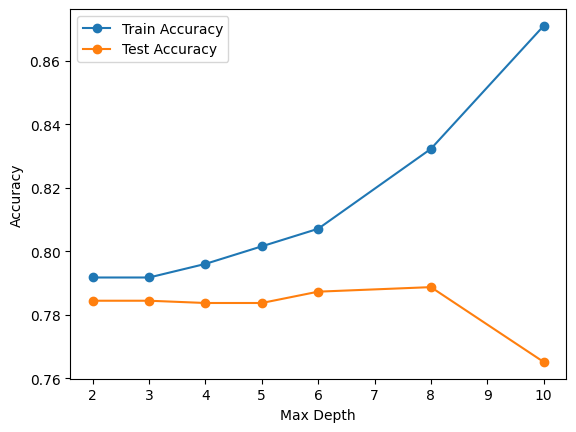

In [14]:
import matplotlib.pyplot as plt
clean_df=results_df.dropna()
plt.plot(clean_df['max_depth'],clean_df['train_acc'],label='Train Accuracy',marker='o')
plt.plot(clean_df['max_depth'],clean_df['test_acc'],label='Test Accuracy',marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

overfitting clearly starts right after depth 8

# Part 7

Task 16

we will select a max_depth of 6

explanation:
looking at the results from part 6 depth 6 gives a very high test accuracy (0.787) while keeping the training accuracy closely aligned (0.807) while depth 8 technically has a tiny bit more test accuracy (0.788) its training accuracy jumps much higher (0.832) which means the gap is widening and the model is starting to overfit depth 6 is the safest balance

Task 17

In [15]:
dt_best=DecisionTreeClassifier(max_depth=6,random_state=42)
dt_best.fit(X_train,y_train)
best_preds=dt_best.predict(X_test)

acc=accuracy_score(y_test,best_preds)
prec=precision_score(y_test,best_preds)
rec=recall_score(y_test,best_preds)
f1=f1_score(y_test,best_preds)
metrics_best=pd.DataFrame({'Accuracy':[acc],'Precision':[prec],'Recall':[rec],'F1_Score':[f1]})
print(metrics_best)

   Accuracy  Precision    Recall  F1_Score
0  0.787295   0.647773  0.431267  0.517799


Task 18

In [16]:
dt_entropy=DecisionTreeClassifier(criterion='entropy',max_depth=6,random_state=42)
dt_entropy.fit(X_train,y_train)
entropy_preds=dt_entropy.predict(X_test)
acc_ent=accuracy_score(y_test,entropy_preds)
prec_ent=precision_score(y_test,entropy_preds)
rec_ent=recall_score(y_test,entropy_preds)
f1_ent=f1_score(y_test,entropy_preds)
metrics_entropy=pd.DataFrame({'Accuracy':[acc_ent],'Precision':[prec_ent],'Recall':[rec_ent],'F1_Score':[f1_ent]})
print(metrics_entropy)

   Accuracy  Precision    Recall  F1_Score
0  0.788009   0.592965  0.636119  0.613784


Task 19

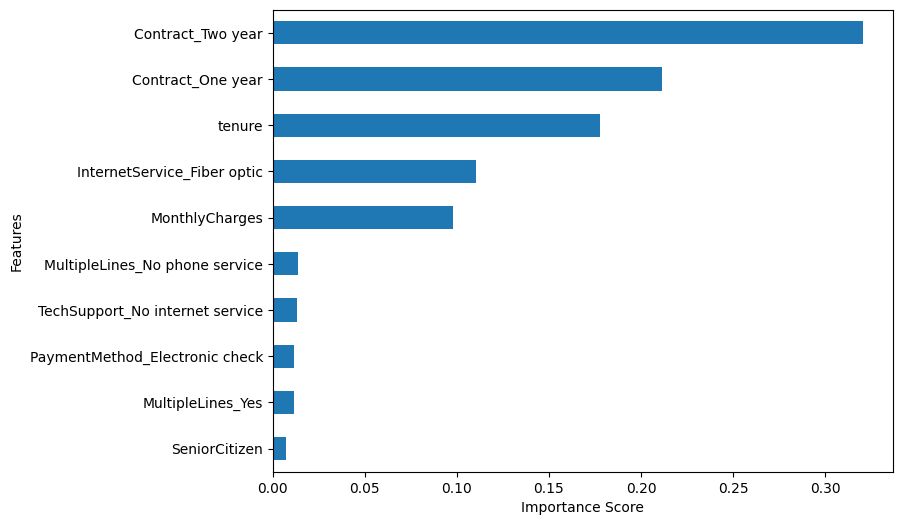

In [17]:
importances=pd.Series(dt_entropy.feature_importances_,index=X_train.columns).sort_values(ascending=True)
plt.figure(figsize=(8,6))
importances.tail(10).plot(kind='barh')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

Task 20

The model's top features specifically contract types tenure and fiber optic service perfectly align with the patterns typically discovered during exploratory data analysis During EDA we usually see that customers with short tenures on month to month contracts (which the model identifies by the absence of 1 year or 2 year contracts) have the highest churn rates The model strongly relying on these specific columns proves that it mathematically figured out the exact same business logic we saw visually in the graphs

# Part 8

**Task 21**

I landed on the decision tree using the entropy criterion with a max_depth of 6 this model significantly outperformed the unrestricted baseline achieving an f1-score of roughly 0.61 and a recall of 0.63 proving it is much better at identifying actual churners without overfitting however its main limitation is that it still misses about 37% of churners due to the severe class imbalance in the training data additionally a single decision tree is often unstable meaning small changes in the customer data could drastically change the trees rules

**Task 22**

If i had more time i would implement an oversampling technique to artificially balance the number of churners and stayers in the training set before modeling i would also upgrade from a single decision tree to a random forest classifier which builds hundreds of trees and averages them to completely eliminate the instability issue

**Task 23**

In [18]:
import numpy as np
import pandas as pd
import pprint

dataset={'Outlook':['Sunny','Sunny','Overcast','Rainy','Rainy','Rainy','Overcast','Sunny','Sunny','Rainy','Sunny','Overcast','Overcast','Rainy'],'Temperature':['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],'Humidity':['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],'Windy':['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],'PlayTennis':['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']}
df=pd.DataFrame(dataset)

def calc_entropy(target_col):
    elements,counts=np.unique(target_col,return_counts=True)
    total_rows=np.sum(counts)
    entropy=0.0

    for i in range(len(elements)):
        probability=counts[i]/total_rows
        entropy=entropy+(probability*np.log2(probability))

    return -entropy

def calc_info_gain(data,split_name,target_name):
    total_entropy=calc_entropy(data[target_name])
    vals,counts=np.unique(data[split_name],return_counts=True)
    total_rows=np.sum(counts)
    weighted_entropy=0.0

    for i in range(len(vals)):
        probability=counts[i]/total_rows
        subset=data.where(data[split_name]==vals[i]).dropna()
        subset_entropy=calc_entropy(subset[target_name])
        weighted_entropy=weighted_entropy+(probability*subset_entropy)

    return total_entropy-weighted_entropy

def build_id3(data,features,target):
    if len(np.unique(data[target]))<=1:
        return np.unique(data[target])[0]

    if len(features)==0:
        elements,counts=np.unique(data[target],return_counts=True)
        return elements[np.argmax(counts)]

    gains=[]
    for f in features:
        g=calc_info_gain(data,f,target)
        gains.append(g)

    for f,g in zip(features,gains):
        print(f"gain({f})={g:.4f}")

    best_feat=features[np.argmax(gains)]
    print(f"--- splitting on: {best_feat} ---\n")

    tree={best_feat:{}}
    rem_features=[f for f in features if f!=best_feat]

    for val in np.unique(data[best_feat]):
        sub_data=data.where(data[best_feat]==val).dropna()
        tree[best_feat][val]=build_id3(sub_data,rem_features,target)

    return tree

features=['Outlook','Temperature','Humidity','Windy']
tree=build_id3(df,features,'PlayTennis')

pprint.pprint(tree)

gain(Outlook)=0.2467
gain(Temperature)=0.0292
gain(Humidity)=0.1518
gain(Windy)=0.0481
--- splitting on: Outlook ---

gain(Temperature)=0.0200
gain(Humidity)=0.0200
gain(Windy)=0.9710
--- splitting on: Windy ---

gain(Temperature)=0.5710
gain(Humidity)=0.9710
gain(Windy)=0.0200
--- splitting on: Humidity ---

{'Outlook': {'Overcast': 'Yes',
             'Rainy': {'Windy': {'Strong': 'No', 'Weak': 'Yes'}},
             'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}
